In [79]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [80]:
diabetes = pd.read_csv('diabetes.csv')
diabetes

,PatientID,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age,Diabetic
0,1354778,0,171,80,34,23,43.509726,1.213191,21,0
1,1147438,8,92,93,47,36,21.240576,0.158365,23,0
2,1640031,7,115,47,52,35,41.511523,0.079019,23,0
3,1883350,9,103,78,25,304,29.582192,1.282870,43,1
4,1424119,1,85,59,27,35,42.604536,0.549542,22,0
...,...,...,...,...,...,...,...,...,...,...
14995,1490300,10,65,60,46,177,33.512468,0.148327,41,1
14996,1744410,2,73,66,27,168,30.132636,0.862252,38,1
14997,1742742,0,93,89,43,57,18.690683,0.427049,24,0
14998,1099353,0,132,98,18,161,19.791645,0.302257,23,0


In [81]:
features = ['Pregnancies','PlasmaGlucose','DiastolicBloodPressure','TricepsThickness','SerumInsulin','BMI','DiabetesPedigree','Age']
target = 'Diabetic'
X, y = diabetes[features], diabetes[target]
print('X:')
display(X)
print('\ny:')
display(y)

X:


,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age
0,0,171,80,34,23,43.509726,1.213191,21
1,8,92,93,47,36,21.240576,0.158365,23
2,7,115,47,52,35,41.511523,0.079019,23
3,9,103,78,25,304,29.582192,1.282870,43
4,1,85,59,27,35,42.604536,0.549542,22
...,...,...,...,...,...,...,...,...
14995,10,65,60,46,177,33.512468,0.148327,41
14996,2,73,66,27,168,30.132636,0.862252,38
14997,0,93,89,43,57,18.690683,0.427049,24
14998,0,132,98,18,161,19.791645,0.302257,23



y:


0        0
1        0
2        0
3        1
4        0
        ..
14995    1
14996    1
14997    0
14998    0
14999    1
Name: Diabetic, Length: 15000, dtype: int64

In [82]:
pd.Series(y).value_counts(normalize = True)

Diabetic
0    0.666667
1    0.333333
Name: proportion, dtype: float64

In [83]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               15000 non-null  int64  
 1   Pregnancies             15000 non-null  int64  
 2   PlasmaGlucose           15000 non-null  int64  
 3   DiastolicBloodPressure  15000 non-null  int64  
 4   TricepsThickness        15000 non-null  int64  
 5   SerumInsulin            15000 non-null  int64  
 6   BMI                     15000 non-null  float64
 7   DiabetesPedigree        15000 non-null  float64
 8   Age                     15000 non-null  int64  
 9   Diabetic                15000 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 1.1 MB


In [84]:
X.describe()

,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,3.224533,107.856867,71.220667,28.814000,137.852133,31.509646,0.398968,30.137733
std,3.391020,31.981975,16.758716,14.555716,133.068252,9.759000,0.377944,12.089703
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200512,0.078044,21.000000
25%,0.000000,84.000000,58.000000,15.000000,39.000000,21.259887,0.137743,22.000000
50%,2.000000,104.000000,72.000000,31.000000,83.000000,31.767940,0.200297,24.000000
75%,6.000000,129.000000,85.000000,41.000000,195.000000,39.259692,0.616285,35.000000
max,14.000000,192.000000,117.000000,93.000000,799.000000,56.034628,2.301594,77.000000


Unique values: 15


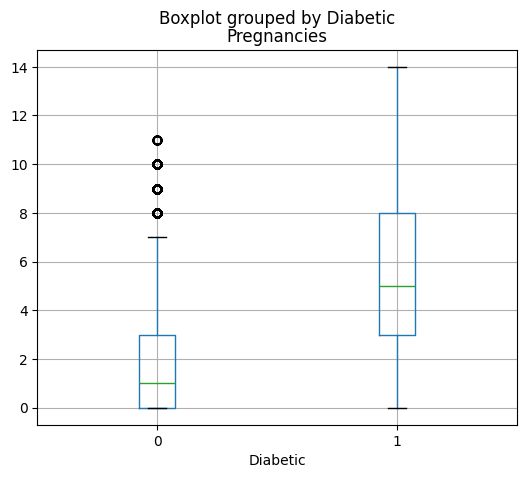

Unique values: 149


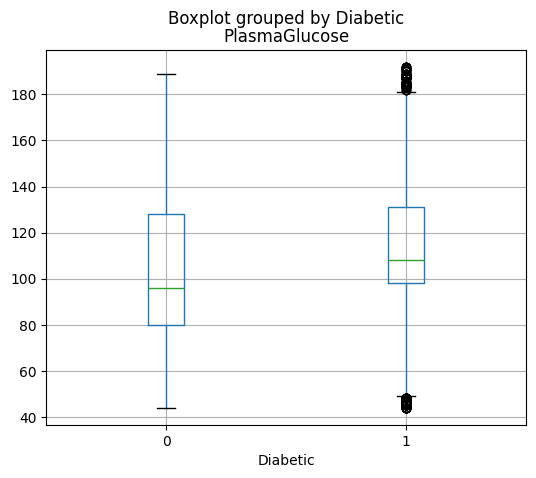

Unique values: 90


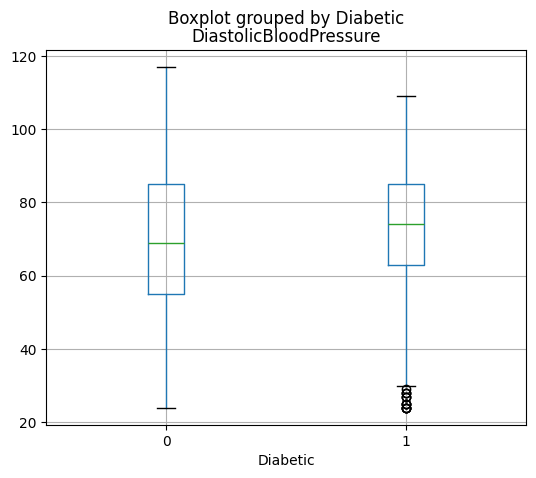

Unique values: 69


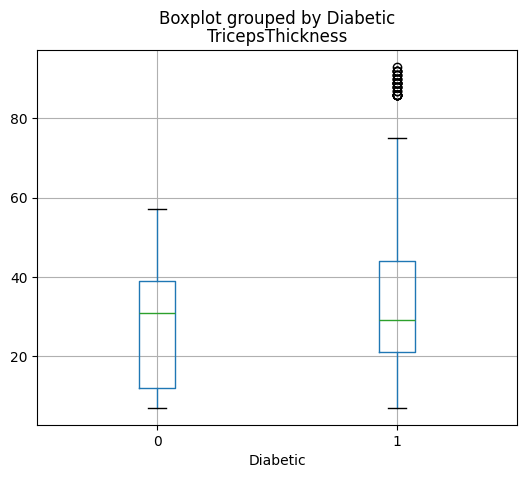

Unique values: 663


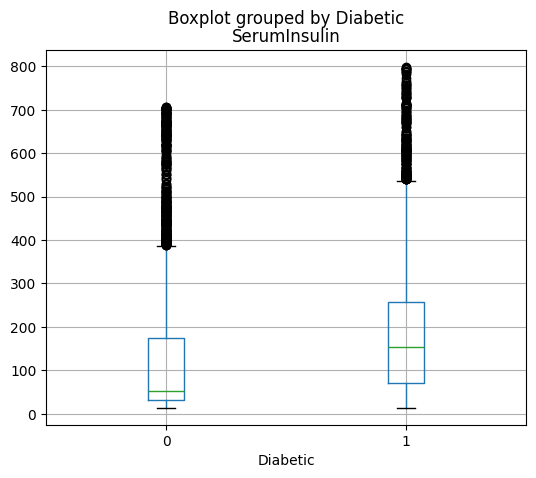

Unique values: 15000


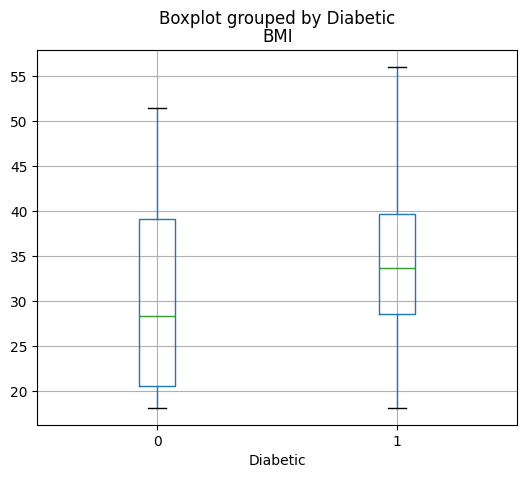

Unique values: 14999


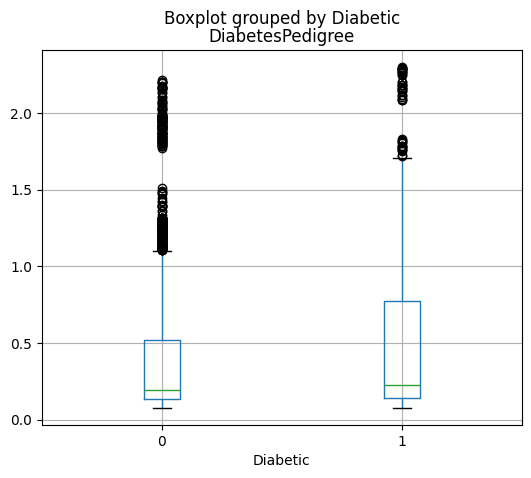

Unique values: 56


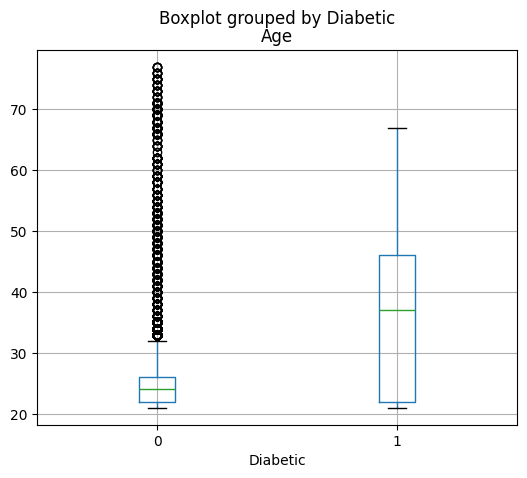

In [85]:
import matplotlib.pyplot as plt
for col in features:
    print(f'Unique values: {len(diabetes[col].unique())}')
    diabetes.boxplot(column=col, by='Diabetic', figsize=(6,5))
    plt.title(col)
    plt.show()

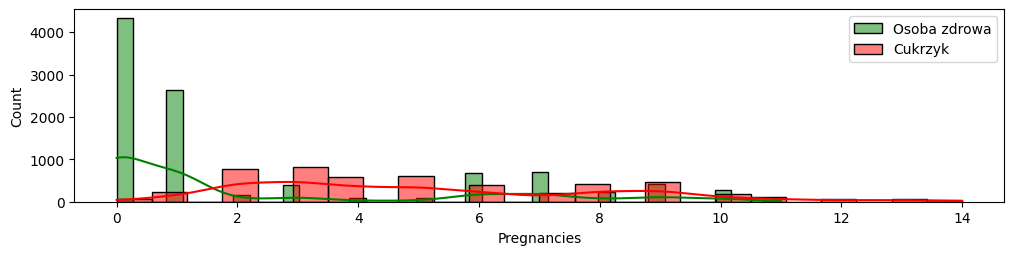

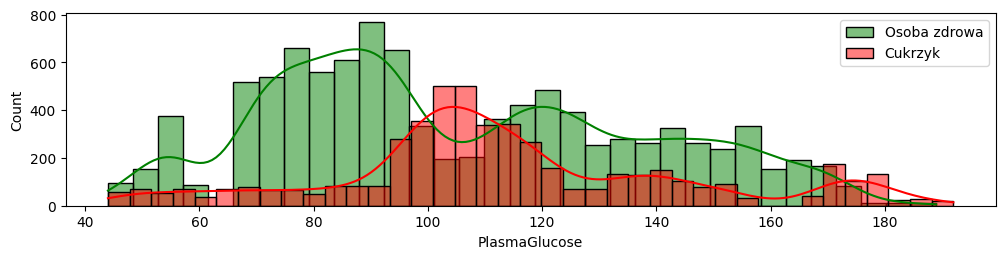

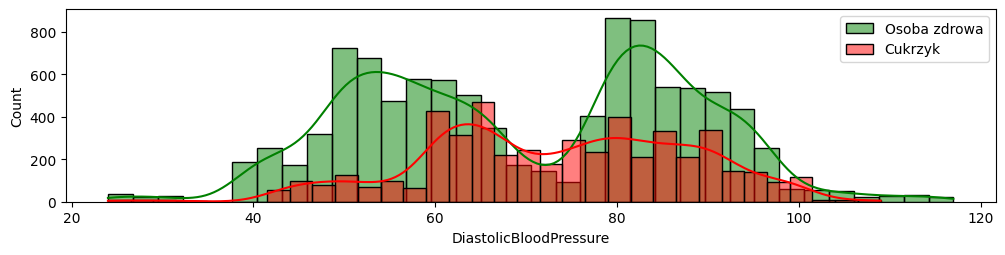

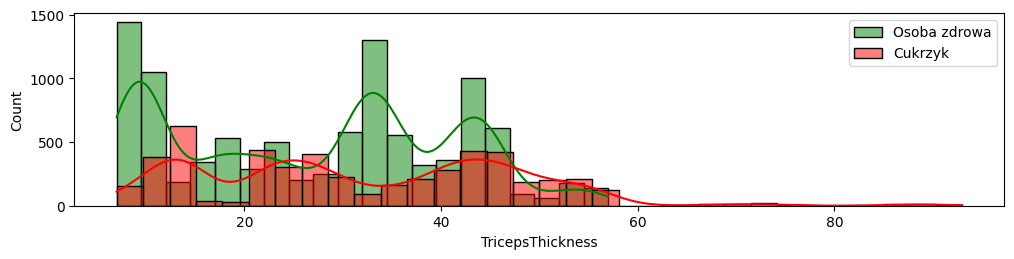

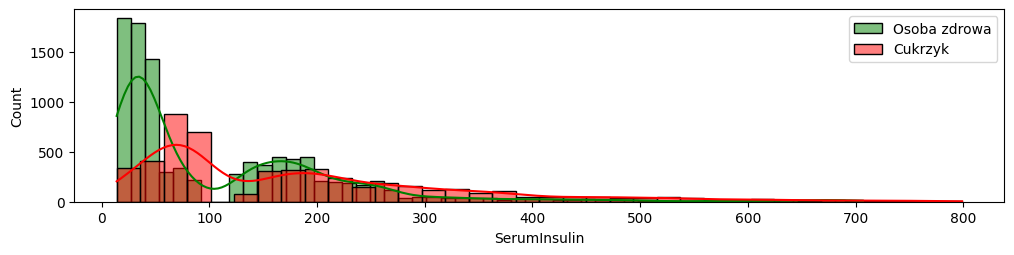

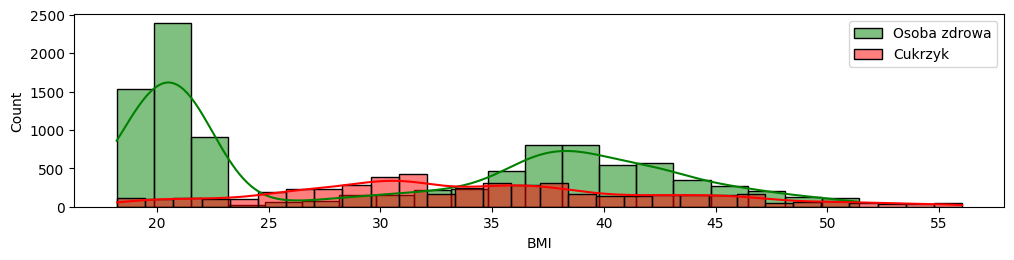

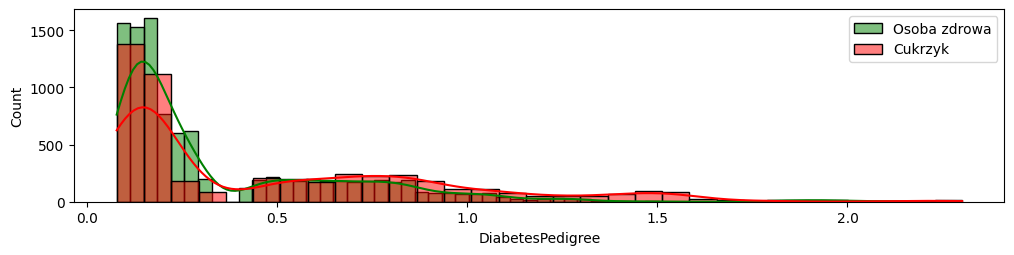

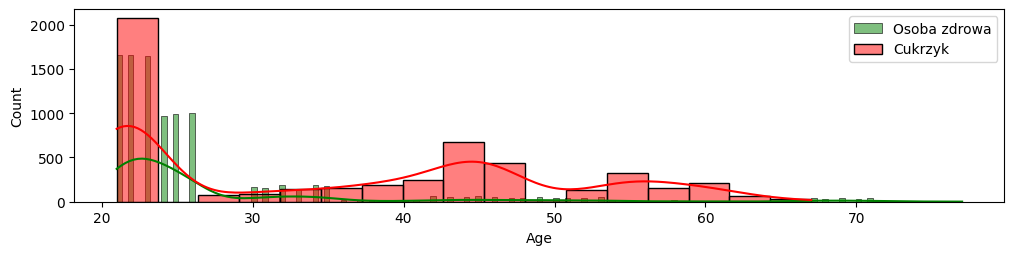

In [86]:
import seaborn as sns
for col in features:
    plt.figure(figsize=(12, 2.5))
    sns.histplot(diabetes.loc[diabetes['Diabetic']==0, col], kde=True, color='green', label='Osoba zdrowa')
    sns.histplot(diabetes.loc[diabetes['Diabetic']==1, col], kde=True, color='red', label='Cukrzyk')
    plt.legend(loc='upper right')
    plt.show()


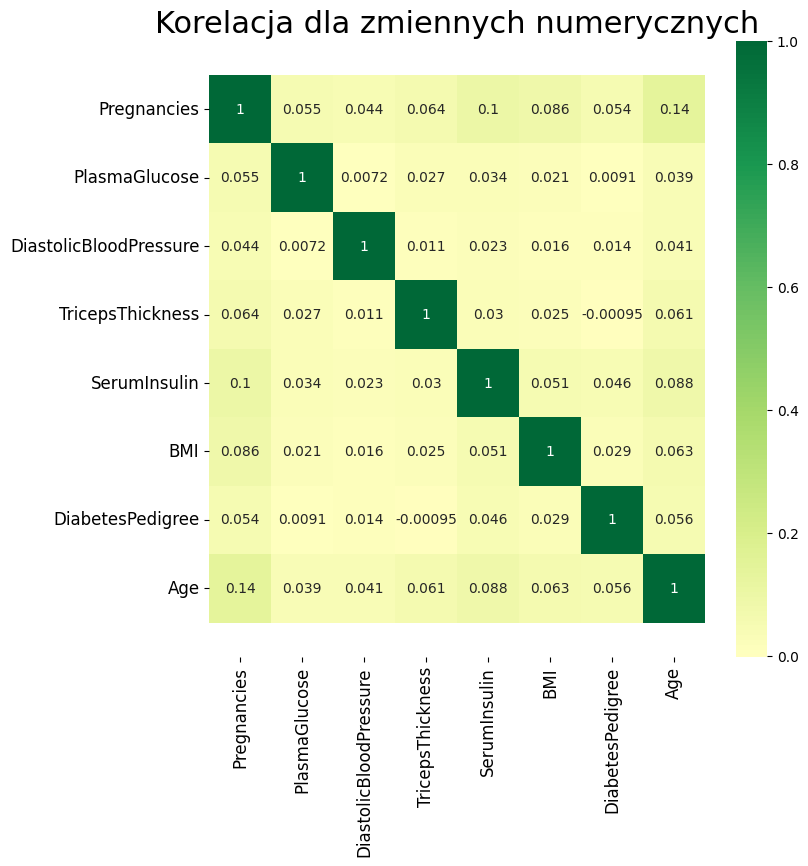

In [87]:
plt.figure(figsize=(8,8))
ax = sns.heatmap(X.corr(),
                 xticklabels=X.corr().columns,
                 yticklabels=X.corr().columns,
                 cmap='RdYlGn',
                 center=0,
                 annot=True)

plt.title('Korelacja dla zmiennych numerycznych', fontsize=22)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [88]:
from scipy import stats

corr_dict = {}
for col in features:
    corr_dict[col] = stats.pointbiserialr(X[col], y)[0]
pd.Series(corr_dict).sort_values(ascending=False)

Pregnancies               0.407315
Age                       0.342605
SerumInsulin              0.247375
BMI                       0.210508
DiabetesPedigree          0.170302
TricepsThickness          0.152505
PlasmaGlucose             0.128004
DiastolicBloodPressure    0.091307
dtype: float64

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X[['Pregnancies', 'Age']], y, test_size=0.30, random_state=0, stratify=y)
print ('Treningowe obserwacje: %d\nTestowe obserwacje: %d' % (X_train.shape[0], X_test.shape[0]))

Treningowe obserwacje: 10500
Testowe obserwacje: 4500


In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler_2var = StandardScaler()
X_train_standarized = scaler_2var.fit_transform(X_train)
X_test_standarized = scaler_2var.fit_transform(X_test)
model_lr = LogisticRegression()
model_lr.fit(X_train_standarized, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

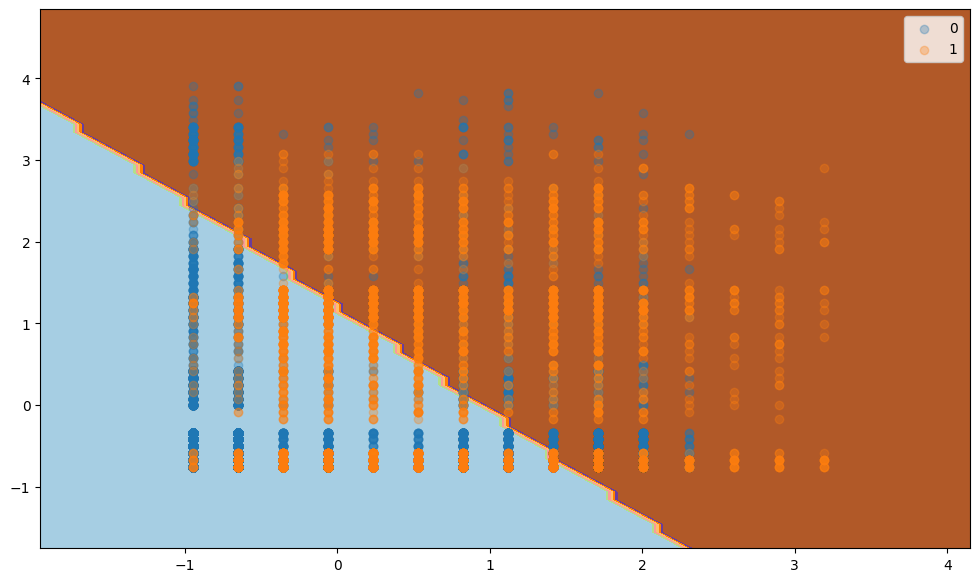

In [91]:
from numpy import where
from numpy import meshgrid
from numpy import hstack
from numpy import arange

def plot_classification_surface(X_plot, y_plot, trained_model):
    plt.figure(figsize=(12,7))
    # określanie graniz zbioru
    min1, max1 = X_plot[:,0].min()-1,X_plot[:,0].max()+1
    min2, max2 = X_plot[:,1].min()-1, X_plot[:,1].max()+1
    # skalowanie dla obu osi
    x1grid = arange(min1,max1,0.1)
    x2grid = arange(min2,max2,0.1)
    #  utworzenie siatki
    xx, yy = meshgrid(x1grid,x2grid)
    #  przetworzenie siatki w wektor
    r1, r2 = xx.flatten(), yy.flatten()
    r1,r2 = r1.reshape((len(r1), 1)), r2.reshape((len(r2),1))

    # stworzenie zmiennych objaśniających dla modelu
    grid = hstack((r1,r2))

    # predykcja modelu zbioru
    yhat = trained_model.predict(grid)
    # przetworzenie predykcji na decyzji dla konkretnego punktu wykresu
    zz = yhat.reshape(xx.shape)
    # wizualizacja siatki z przyporządkowaną klasą
    plt.contourf(xx,yy,zz, cmap='Paired')
    # tworzenie wykresu punktowego dla klas ze zbioru X
    for class_value in range (2):
        # przyporzadkowanie klasy (y) do obserwacji (X)
        row_ix = where(y_plot == class_value)
        # stworzenie wykresu punktowego
        plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)
    #  wizualizacja wykresu
    plt.legend(loc='upper right')
    plt.show()
plot_classification_surface(X_plot=X_train_standarized, y_plot=y_train, trained_model=model_lr)

In [92]:
predictions_lr = model_lr.predict(X_test_standarized)
print('Predicted labes : ', predictions_lr[:5], predictions_lr[-5:])
print('Actual labels:    ', y_test[:5].values, y_test[-5:].values)

Predicted labes :  [0 0 1 0 0] [1 0 1 0 0]
Actual labels:     [0 1 0 0 0] [1 1 0 0 0]


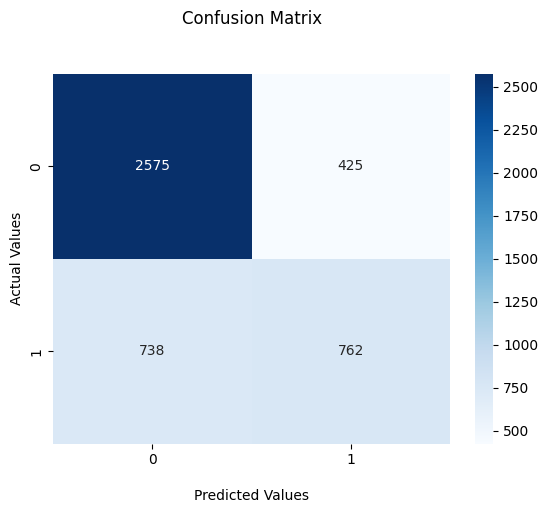

In [93]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test,predictions_lr)
ax = sns.heatmap(cm, annot=True, cmap='Blues', fmt='.0f')
ax.set_title('Confusion Matrix\n\n')
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values')
plt.show()

In [94]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print('Accuracy:   ', accuracy_score(y_test, predictions_lr))
print('Precision:  ',precision_score(y_test, predictions_lr))
print('Recall:     ',recall_score(y_test, predictions_lr))
print('F1_score:   ',f1_score(y_test, predictions_lr))

Accuracy:    0.7415555555555555
Precision:   0.6419545071609098
Recall:      0.508
F1_score:    0.5671752884257536


In [95]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions_lr))

              precision    recall  f1-score   support

           0       0.78      0.86      0.82      3000
           1       0.64      0.51      0.57      1500

    accuracy                           0.74      4500
   macro avg       0.71      0.68      0.69      4500
weighted avg       0.73      0.74      0.73      4500



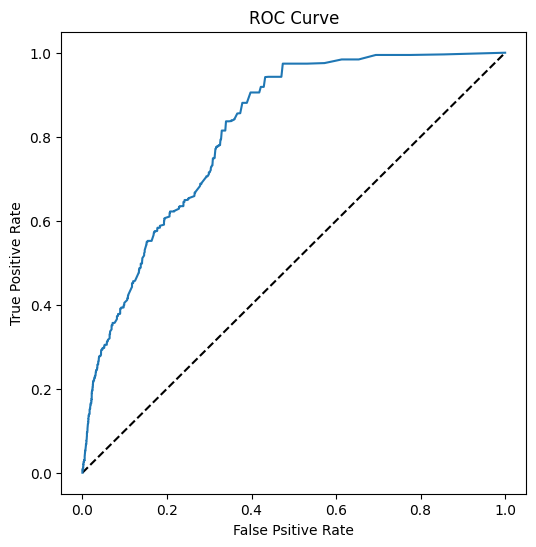

AUC:  0.8160451111111111


In [96]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# prognoza prawdopodobieństwa
predictions_probability_lr = model_lr.predict_proba(X_test_standarized)
# obliczenie FPR oraz TPR w zależności od punktu odcięcia
fpr, tpr, thresholds = roc_curve(y_test, predictions_probability_lr[:,1])
# wizualizacaja ROC Curve
fig = plt.figure(figsize=(6,6))
# rysowanie prostej dla modelu losowego
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Psitive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

# obliczenie AUC
auc = roc_auc_score(y_test, predictions_probability_lr[:,1])
print('AUC:  ' + str(auc))

In [97]:
metrics_dataframe = pd.DataFrame(columns = ['Model', 'F1_score', 'AUC'])
metrics_dataframe
models = []
models_names = []
predictions_proba_list =[]

def calculate_metrics(model, name, X_checked, y_checked):
    models.append(model)
    models_names.append(name)
    global metrics_dataframe
    predictions = model.predict(X_checked)
    predictions_proba = model.predict_proba(X_checked)
    predictions_proba_list.append(predictions_proba[:,1])
    # ####### metryki dla sprawdzanego modelu
    # Precission, Recall, F1, Accuracy
    print(classification_report(y_checked,predictions))

    # Confusion matrix
    plt.figure()
    cm = confusion_matrix(y_checked, predictions)
    ax = sns.heatmap(cm, annot=True, cmap='Blues', fmt='.0f')
    ax.set_title('Confusion Matrix\n\n')
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual VAlues  ')
    plt.show()

    # plot ROC curve
    fig = plt.figure(figsize=(6,6))
    plt.plot([0,1],[0,1], 'k--')
    for model_selected, name_selected, pred_proba in zip(models, models_names, predictions_proba_list):
        fpr,tpr,threshold = roc_curve(y_checked, pred_proba)
        plt.plot(fpr, tpr, label=name_selected)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    f1_metric = f1_score(y_checked, predictions)
    auc_metric = roc_auc_score(y_checked, predictions_proba[:,1])
    metrics_dataframe.loc[len(metrics_dataframe)] = {
    'Model': name,
    'F1_score': f1_metric,
    'AUC': auc_metric
    }
    return metrics_dataframe
    


              precision    recall  f1-score   support

           0       0.78      0.86      0.82      3000
           1       0.64      0.51      0.57      1500

    accuracy                           0.74      4500
   macro avg       0.71      0.68      0.69      4500
weighted avg       0.73      0.74      0.73      4500



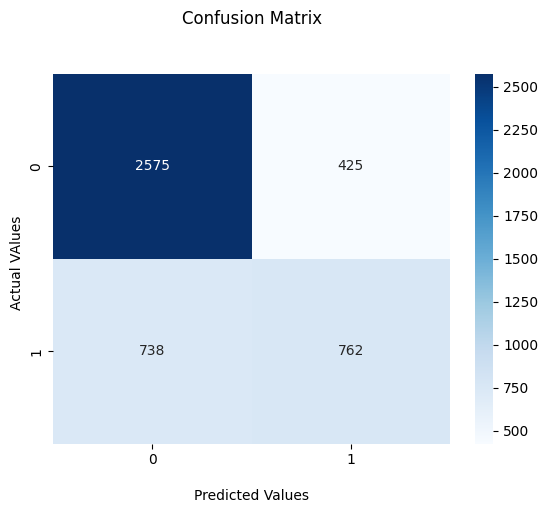

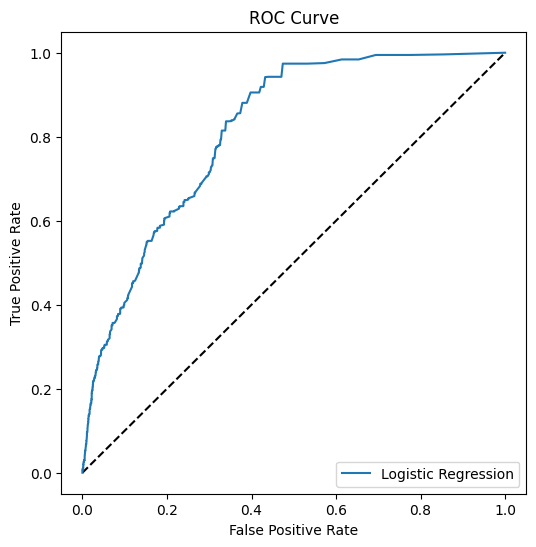

,Model,F1_score,AUC
0,Logistic Regression,0.567175,0.816045


In [98]:
calculate_metrics(model_lr, 'Logistic Regression', X_test_standarized, y_test)

In [99]:
help(LogisticRegression)

Help on class LogisticRegression in module sklearn.linear_model._logistic:

class LogisticRegression(sklearn.callback._callback_support.CallbackSupportMixin, sklearn.linear_model._base.LinearClassifierMixin, sklearn.linear_model._base.SparseCoefMixin, sklearn.base.BaseEstimator)
 |  LogisticRegression(penalty='deprecated', *, C=1.0, l1_ratio=0.0, dual=False, tol=0.0001, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, verbose=0, warm_start=False, n_jobs=None)
 |  
 |  Logistic Regression (aka logit, MaxEnt) classifier.
 |  
 |  This class implements regularized logistic regression using a set of available
 |  solvers. **Note that regularization is applied by default**. It can handle both
 |  dense and sparse input `X`. Use C-ordered arrays or CSR matrices containing 64-bit
 |  floats for optimal performance; any other input format will be converted (and
 |  copied).
 |  
 |  The solvers 'lbfgs', 'newton-cg', 'newton-cholesky' 

In [113]:
values = []
for i in range(10):
    values.append(0.00000001 * 10**i)
for penalty in ['l1','l2']:
    for C in values:
        name = f'{penalty.upper()}_C_{C}'
        # print(name)
        model = LogisticRegression(penalty=penalty,C=C,solver='liblinear')
        model.fit(X_train_standarized, y_train)
        prediction_train = model.predict(X_train_standarized)
        prediction_test = model.predict(X_test_standarized)
        f1_score_train = f1_score(y_train, prediction_train)
        f1_score_test = f1_score(y_test, prediction_test)
        print(f'for - {name}')
        print('F1 train:', f1_score_train)
        print('F1 test :', f1_score_test)



for - L1_C_1e-08
F1 train: 0.0
F1 test : 0.0
for - L1_C_1e-07
F1 train: 0.0
F1 test : 0.0
for - L1_C_1e-06
F1 train: 0.0
F1 test : 0.0
for - L1_C_1e-05
F1 train: 0.0
F1 test : 0.0
for - L1_C_0.0001
F1 train: 0.0
F1 test : 0.0
for - L1_C_0.001
F1 train: 0.5383647798742138
F1 test : 0.5637727759914255
for - L1_C_0.01
F1 train: 0.5464035230794324
F1 test : 0.569423929098966
for - L1_C_0.1
F1 train: 0.5468775476928094
F1 test : 0.5671752884257536
for - L1_C_1.0
F1 train: 0.5468775476928094
F1 test : 0.5671752884257536
for - L1_C_10.0
F1 train: 0.5468775476928094
F1 test : 0.5671752884257536
for - L2_C_1e-08
F1 train: 0.5631688228717457
F1 test : 0.5852066715010877
for - L2_C_1e-07
F1 train: 0.5631688228717457
F1 test : 0.5852066715010877
for - L2_C_1e-06
F1 train: 0.5631688228717457
F1 test : 0.5852066715010877
for - L2_C_1e-05
F1 train: 0.5616504078042539
F1 test : 0.5860566448801743
for - L2_C_0.0001
F1 train: 0.5614203454894434
F1 test : 0.5845147219193021
for - L2_C_0.001
F1 train: 0.5

W tym miejscu wypada maksimum dla test
for - L2_C_1e-05
F1 train: 0.5616504078042539
F1 test : 0.5860566448801743

L1, C=0.0001


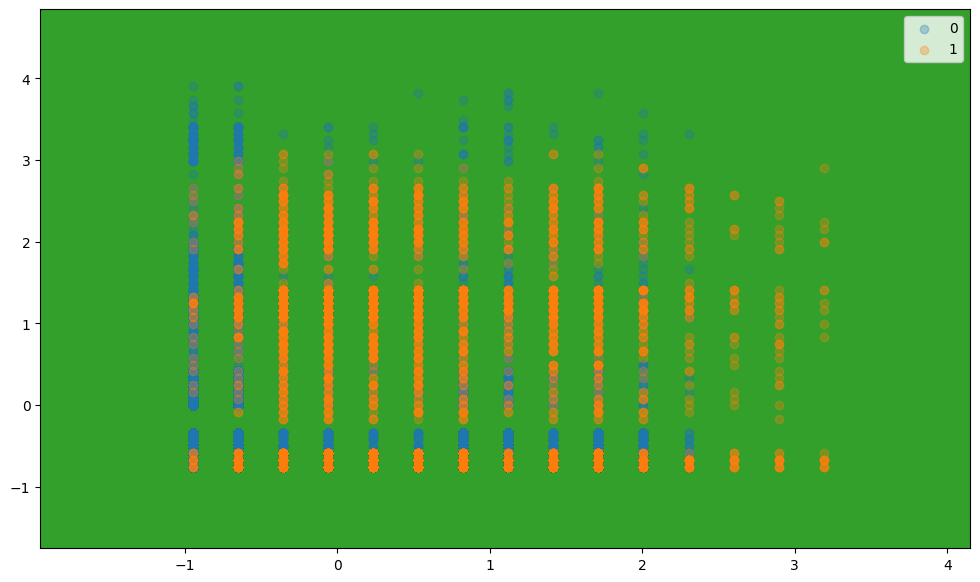

              precision    recall  f1-score   support

           0       0.67      1.00      0.80      3000
           1       0.00      0.00      0.00      1500

    accuracy                           0.67      4500
   macro avg       0.33      0.50      0.40      4500
weighted avg       0.44      0.67      0.53      4500



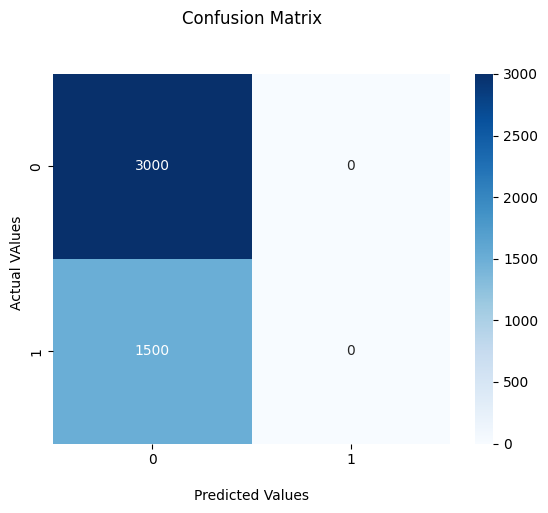

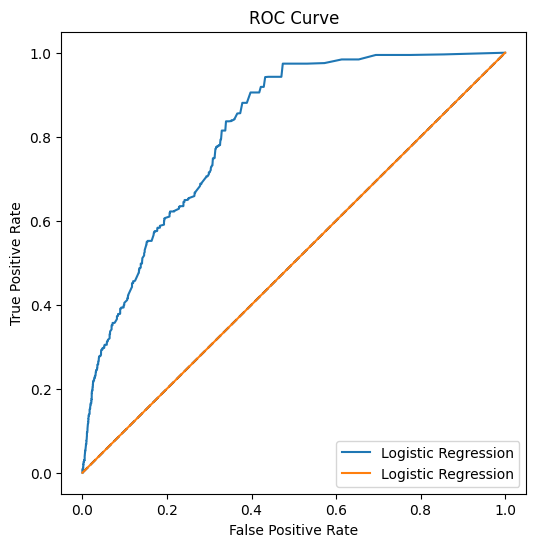

L1, C=0.01


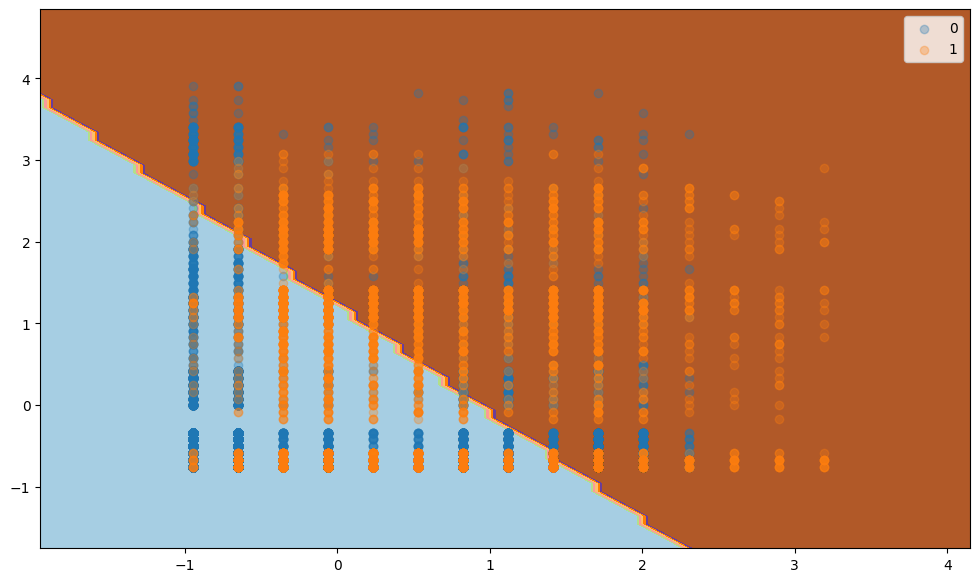

              precision    recall  f1-score   support

           0       0.78      0.85      0.81      3000
           1       0.64      0.51      0.57      1500

    accuracy                           0.74      4500
   macro avg       0.71      0.68      0.69      4500
weighted avg       0.73      0.74      0.73      4500



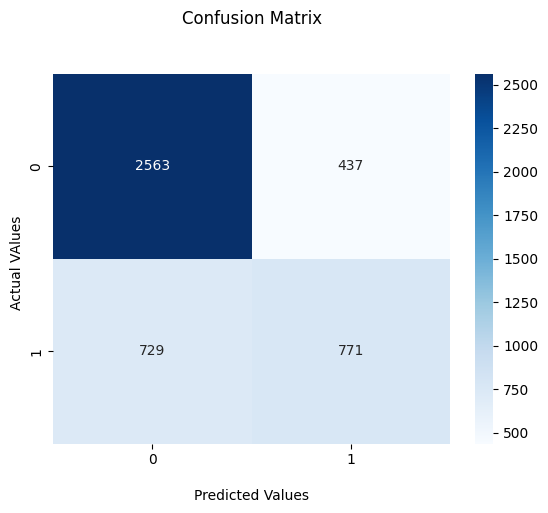

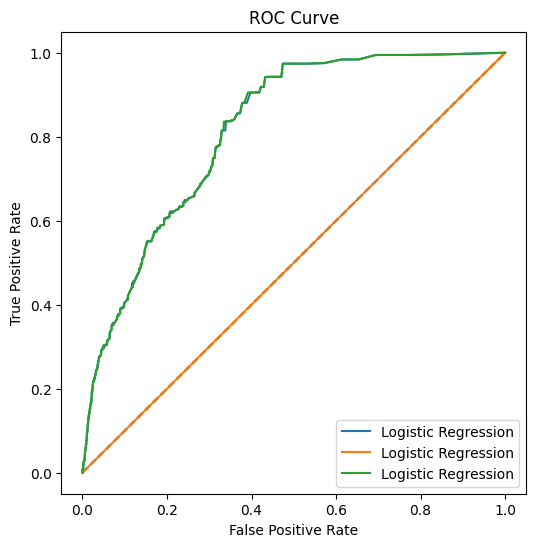

L2, C=1e-05


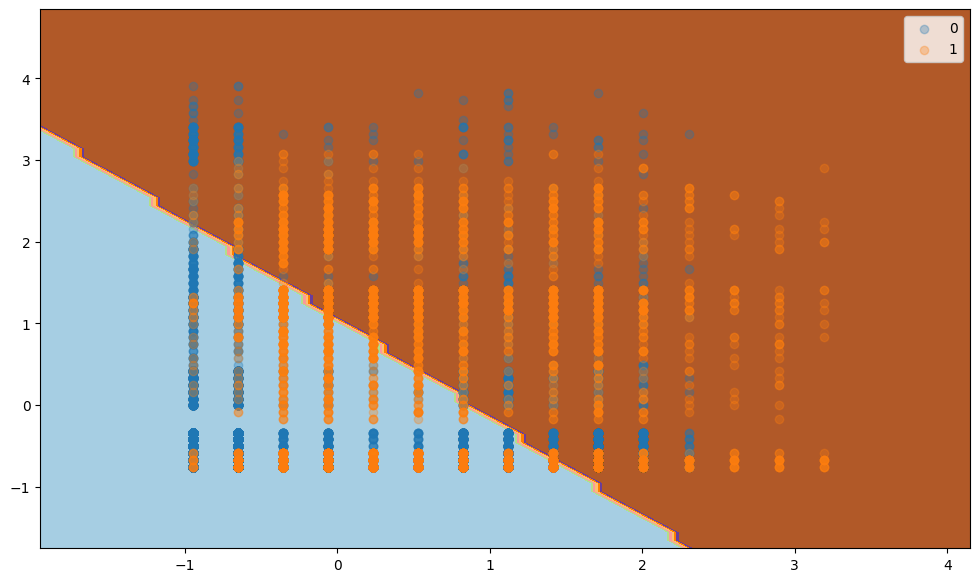

              precision    recall  f1-score   support

           0       0.79      0.85      0.82      3000
           1       0.64      0.54      0.59      1500

    accuracy                           0.75      4500
   macro avg       0.72      0.69      0.70      4500
weighted avg       0.74      0.75      0.74      4500



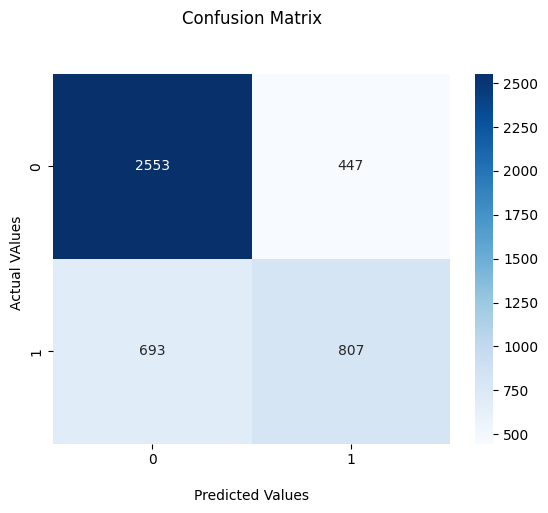

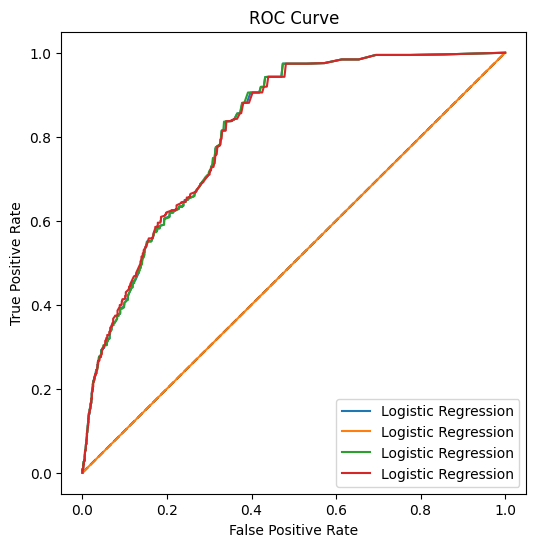

L2, C=0.1


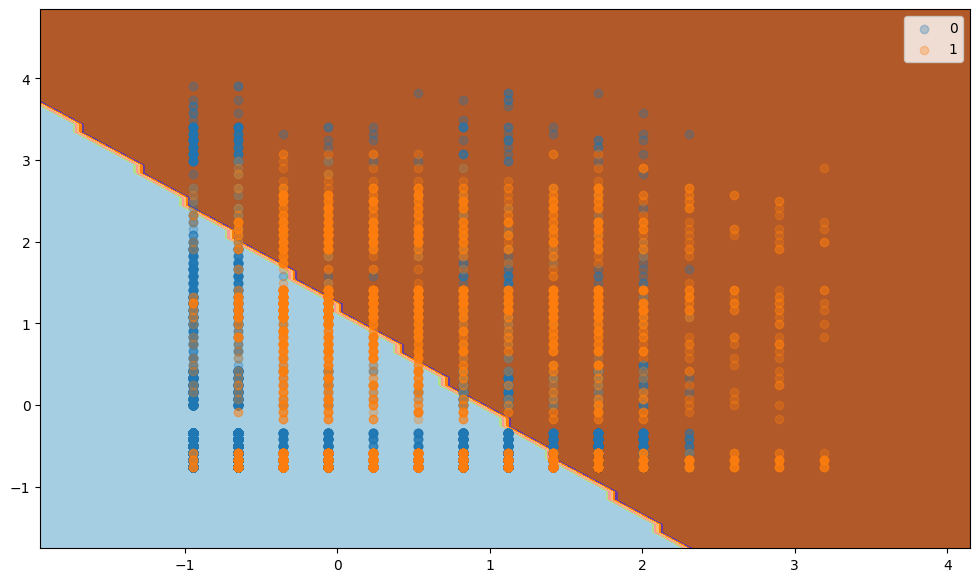

              precision    recall  f1-score   support

           0       0.78      0.86      0.82      3000
           1       0.64      0.51      0.57      1500

    accuracy                           0.74      4500
   macro avg       0.71      0.68      0.69      4500
weighted avg       0.73      0.74      0.73      4500



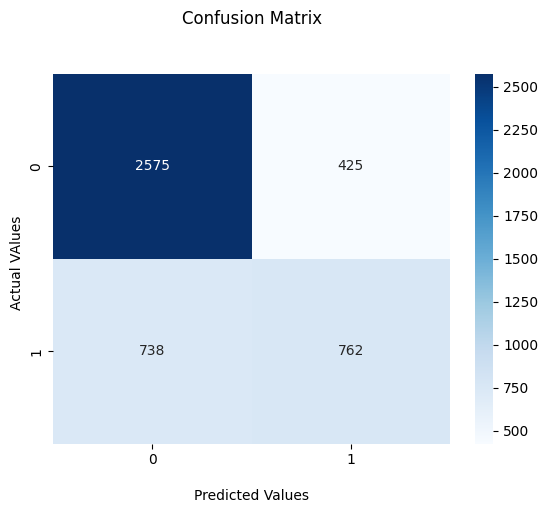

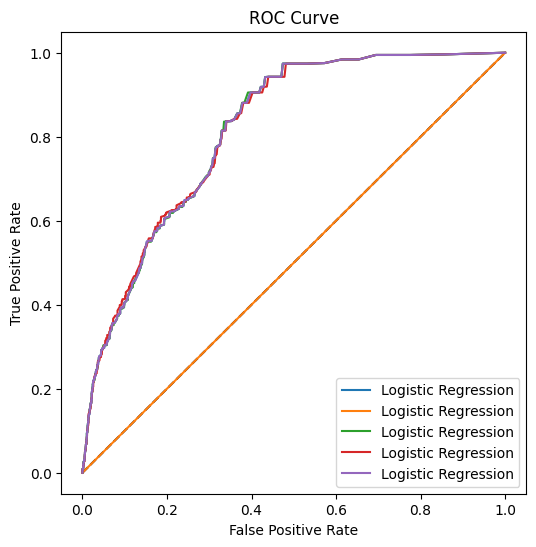

In [115]:
interesting_models = [
    ('L1', 0.0001),
    ('L1', 0.01),
    ('L2', 0.00001),
    ('L2', 0.1)
]
for penalty, C in interesting_models:

    model = LogisticRegression(
        penalty=penalty.lower(),
        C=C,
        solver='liblinear'
    )

    model.fit(X_train_standarized, y_train)

    print(f'{penalty}, C={C}')

    plot_classification_surface(
        X_plot=X_train_standarized,
        y_plot=y_train,
        trained_model=model
    )
    calculate_metrics(model, 'Logistic Regression', X_test_standarized, y_test)

Nie zaobserwowałem szczególnie dużych zmian dla różnych regularyzacji i ich stopnia.
Najlepsze wyniki dla L2, C=1e-05:
accuracy = 0.75
precision 0 = 0.79
precision 1 = 0.64
Przy L1, C=0.0001 model praktycznie przesatł działać, wszędzie przewiduje tę samą klasę.
Róznice między wartościami testowymi i treningowymi są niewielkie i nie wskazują na przeuczenie modelu.